# 3.1 Gradients through chaos

Gradients in Parts 1 and 2 were well behaved because the simple models there were stable:
perturbations decayed, so derivatives through long integrations stayed bounded. Atmospheric models are chaotic,
small differences grow exponentially. This chapter is about what this error growth 
does to gradients. The central problem is a gradient that is computed exactly yet tells you nothing useful about climate. It measures the sensitivity of one trajectory, not of the climate statistics or system properties you care about.

To demonstrate this concept we will use **Lorenz-96** {cite}`lorenz1996predictability`: $K = 40$
variables on a ring, each following

$$\frac{du_k}{dt} = (u_{k+1} - u_{k-2})\,u_{k-1} - u_k + F,$$

with quadratic terms that mimic advection, linear damping, and a constant forcing
$F$. For $F = 8$ the system is chaotic, and it has served as the community's
minimal weather system for decades.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [2]:
# --- The Lorenz-96 model: K variables on a ring, quadratic "advection",
#     linear damping, constant forcing F. Chaotic for F = 8.
K = 40
DT = 0.01

def l96_tendency(u, F):
    return (jnp.roll(u, -1) - jnp.roll(u, 2)) * jnp.roll(u, 1) - u + F

def rk4_step(u, F):
    k1 = l96_tendency(u, F)
    k2 = l96_tendency(u + 0.5 * DT * k1, F)
    k3 = l96_tendency(u + 0.5 * DT * k2, F)
    k4 = l96_tendency(u + DT * k3, F)
    return u + DT / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)

def rollout(u0, F, n_steps):
    def one(u, _):
        u = rk4_step(u, F)
        return u, u
    return jax.lax.scan(one, u0, None, length=n_steps)

key = jax.random.key(0)
u_start = 8.0 + 0.5 * jax.random.normal(key, (K,))
u_spun, _ = rollout(u_start, 8.0, 2000)          # 20 time units of spin-up

## Chaos, measured

Two integrations initialized from states differing by $10^{-8}$ in one variable diverge until they
are as different as two unrelated weather states. The growth rate (the slope of the
line below) is the leading **Lyapunov exponent** $\lambda$.

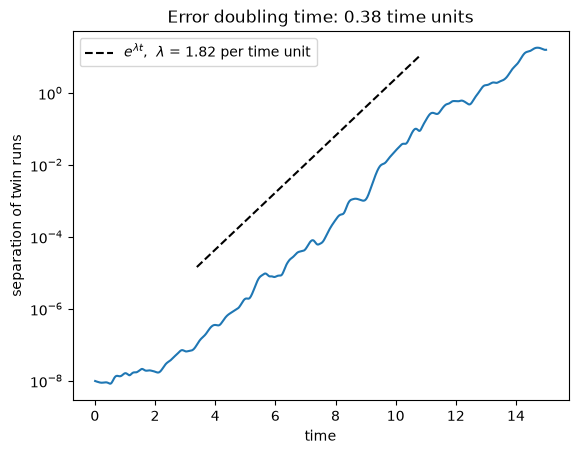

In [3]:
_, traj_a = rollout(u_spun, 8.0, 1500)
_, traj_b = rollout(u_spun.at[0].add(1e-8), 8.0, 1500)
separation = jnp.linalg.norm(traj_a - traj_b, axis=1)
t = jnp.arange(1, 1501) * DT

growing = (separation > 1e-7) & (separation < 1e-1)     # the clean exponential range
lam = jnp.polyfit(t[growing], jnp.log(separation[growing]), 1)[0]

plt.semilogy(t, separation)
plt.semilogy(t[growing], jnp.exp(lam * t[growing]) * 1e-8 * 3, "k--",
             label=f"$e^{{\\lambda t}}$,  $\\lambda$ = {float(lam):.2f} per time unit")
plt.xlabel("time"); plt.ylabel("separation of twin runs")
plt.legend(); plt.title(f"Error doubling time: {float(jnp.log(2)/lam):.2f} time units")
plt.show()

$\lambda \approx 1.8$ per model time unit — errors double roughly every 0.4 units.

## The Part 2 workflow, applied to a chaotic system

Chapter 2.2: a trajectory misfit against observations of a truth run, then
`grad`. The code is identical; only the model changed. The gradient of the misfit with
respect to $F$, as a function of how long a window the misfit covers:

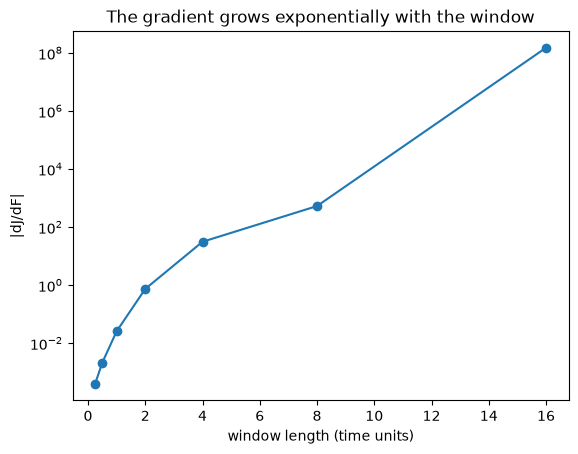

window  0.25:  dJ/dF = +4.029e-04
window  0.50:  dJ/dF = +2.152e-03
window  1.00:  dJ/dF = +2.582e-02
window  2.00:  dJ/dF = +7.428e-01
window  4.00:  dJ/dF = +3.130e+01
window  8.00:  dJ/dF = +5.324e+02
window 16.00:  dJ/dF = -1.522e+08


In [4]:
_, truth = rollout(u_spun, 8.0, 1600)

def trajectory_misfit(F, n_steps):
    _, traj = rollout(u_spun, F, n_steps)
    return jnp.mean((traj - truth[:n_steps]) ** 2)

windows = [25, 50, 100, 200, 400, 800, 1600]
grads = [float(jax.grad(trajectory_misfit)(8.01, n)) for n in windows]

plt.semilogy(jnp.array(windows) * DT, jnp.abs(jnp.array(grads)), "o-")
plt.xlabel("window length (time units)"); plt.ylabel("|dJ/dF|")
plt.title("The gradient grows exponentially with the window")
plt.show()
for n, g in zip(windows, grads):
    print(f"window {n*DT:5.2f}:  dJ/dF = {g:+.3e}")

The gradient through chaos grows exponentially with the length of the integration window. Twelve orders of magnitude between a quarter-unit window and a sixteen-unit one.
The mechanism is the chain rule itself: the derivative of the state at time $t$ with
respect to anything earlier contains the product of the model's Jacobians along the
trajectory, and in a chaotic system that product grows like $e^{\lambda t}$
{cite}`metz2021gradients`. Nothing is numerically wrong — each of these gradients is
the exact derivative of the code. The problem is what the derivative *is*: the
sensitivity of one particular weather trajectory, an object that changes utterly under
infinitesimal perturbation.

The loss surface tells the same story from a different angle:

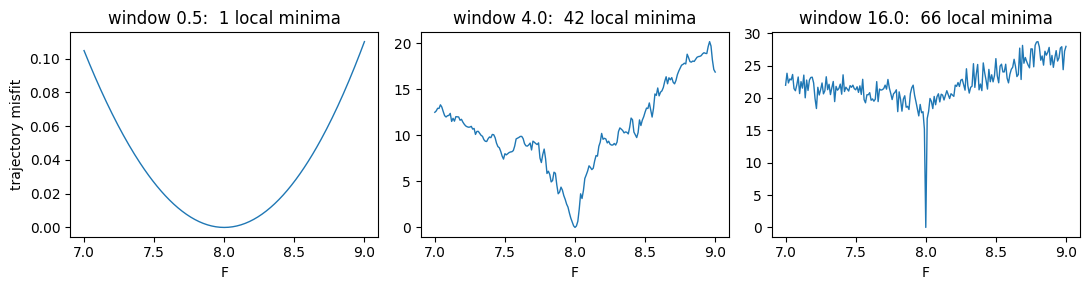

In [5]:
F_values = jnp.linspace(7.0, 9.0, 201)
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True)
for ax, n in zip(axes, [50, 400, 1600]):
    J = jax.vmap(lambda F: trajectory_misfit(F, n))(F_values)
    n_minima = int(jnp.sum((J[1:-1] < J[:-2]) & (J[1:-1] < J[2:])))
    ax.plot(F_values, J, lw=1)
    ax.set_title(f"window {n*DT:.1f}:  {n_minima} local minima")
    ax.set_xlabel("F")
axes[0].set_ylabel("trajectory misfit")
plt.tight_layout(); plt.show()

At a half-unit window the misfit is a clean bowl with its minimum at the true
$F = 8$. At sixteen units it has dozens of local minima and gradient descent from any
distance is hopeless. And the roughness is not a plotting artifact that longer
averaging smooths away — it persists at *every* magnification. The cell below zooms
into an interval of $F$ one millionth of a unit wide; the loss still jumps around, and
its local slopes are a million times steeper:

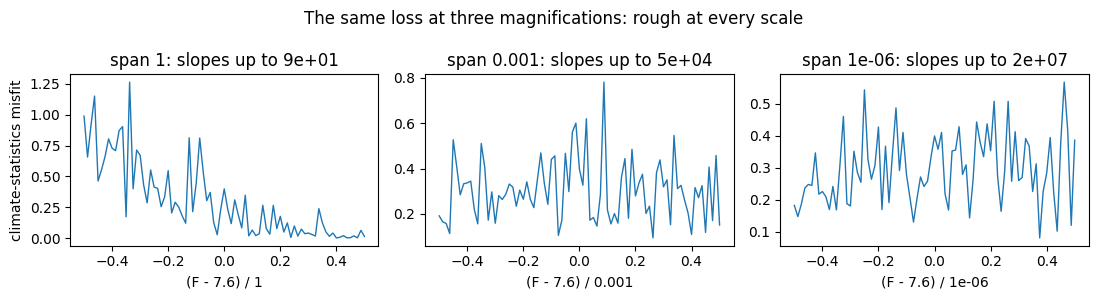

In [6]:
def stats_misfit(F, n_steps=2000):
    """A 'climate' loss: misfit of the mean and variance over a 20-unit window."""
    _, traj = rollout(u_spun, F, n_steps)
    return (jnp.mean(traj) - jnp.mean(truth)) ** 2 \
           + 0.1 * (jnp.mean(traj**2) - jnp.mean(truth**2)) ** 2

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, span in zip(axes, [1.0, 1e-3, 1e-6]):
    Fs = 7.6 + span * jnp.linspace(-0.5, 0.5, 81)
    J = jax.vmap(stats_misfit)(Fs)
    slopes = jnp.diff(J) / jnp.diff(Fs)
    ax.plot((Fs - 7.6) / span, J, lw=1)
    ax.set_title(f"span {span:g}: slopes up to {float(jnp.max(jnp.abs(slopes))):.0e}")
    ax.set_xlabel(f"(F - 7.6) / {span:g}")
axes[0].set_ylabel("climate-statistics misfit")
plt.suptitle("The same loss at three magnifications: rough at every scale")
plt.tight_layout(); plt.show()

This is the shape of every finite-window climate statistic of a chaotic model: a
smooth-looking *envelope* (which answers the climate question) decorated with
microscopic structure (which reflects the particular weather realized in the window).
Automatic differentiation, being exact, differentiates the microstructure. The
envelope is what you wanted; the derivative you computed is of the wiggles.

## Fix 1: ask a short-window question

Within a window shorter than a few doubling times, the trajectory *is* predictable and
its sensitivity is meaningful — this is precisely why operational 4D-Var works over
6–12-hour windows and why Chapter 2.3's method transfers to weather models unchanged.
Calibrating $F$ on a one-unit window converges immediately:

In [7]:
import optax

F_hat, opt = jnp.array(7.0), optax.adam(0.05)
state = opt.init(F_hat)
step = jax.jit(jax.value_and_grad(lambda F: trajectory_misfit(F, 100)))
for i in range(100):
    L, g = step(F_hat)
    updates, state = opt.update(g, state)
    F_hat = optax.apply_updates(F_hat, updates)
print(f"short-window calibration: F = {float(F_hat):.4f}   (truth 8)")

short-window calibration: F = 7.9981   (truth 8)


## Fix 2: truncate the gradient

For genuinely climatic targets — statistics over windows far longer than a doubling
time — the standard escape is to keep the *forward* model exact but stop the
*derivative* from propagating across segment boundaries: `jax.lax.stop_gradient` on
the state every $n$ steps. The result is a **biased but bounded** estimate: it captures
how $F$ influences the statistics within each segment and gives up the exploding
inter-segment terms. (Readers from the neural-network world know this as truncated
backpropagation through time.)

In [8]:
def rollout_truncated(u0, F, n_segments, seg_steps):
    def segment(u, _):
        u = jax.lax.stop_gradient(u)         # derivative does not cross this line
        u, traj = jax.lax.scan(lambda v, __: (rk4_step(v, F),) * 2, u, None, length=seg_steps)
        return u, traj
    _, segs = jax.lax.scan(segment, u0, None, length=n_segments)
    return segs.reshape(-1, K)

def stats_misfit_truncated(F):
    traj = rollout_truncated(u_spun, F, n_segments=40, seg_steps=50)   # 20 units total
    return (jnp.mean(traj) - jnp.mean(truth)) ** 2 \
           + 0.1 * (jnp.mean(traj**2) - jnp.mean(truth**2)) ** 2

print("F      full gradient        truncated gradient")
for F in [7.0, 7.5, 8.0, 8.5]:
    g_full = jax.grad(stats_misfit)(jnp.float64(F))
    g_trunc = jax.grad(stats_misfit_truncated)(jnp.float64(F))
    print(f"{F}   {float(g_full):+14.3e}     {float(g_trunc):+10.4f}")

F_hat, opt = jnp.array(7.0), optax.adam(0.05)
state = opt.init(F_hat)
step = jax.jit(jax.value_and_grad(stats_misfit_truncated))
for i in range(80):
    L, g = step(F_hat)
    updates, state = opt.update(g, state)
    F_hat = optax.apply_updates(F_hat, updates)
print(f"\ntruncated-gradient climate calibration: F = {float(F_hat):.3f}   (truth 8)")

F      full gradient        truncated gradient


7.0       -2.316e+08        -0.8097


7.5       -6.709e+10        -0.5369


8.0       +1.556e+11        +0.0225


8.5       -3.055e+15        +0.6766



truncated-gradient climate calibration: F = 8.099   (truth 8)


The full gradients are astronomical and wildly sign-inconsistent; the truncated ones
are order one, vary smoothly, point downhill toward $F = 8$ — and the calibration
converges. The bias is real (the truncated gradient is not the derivative of anything
exactly) and problem-dependent; segment length is a tuning knob trading bias against
explosion, best chosen near a few doubling times. This same mechanism — differentiate
the physics over short horizons only — underlies most successful online closure
training in chaotic models, including how rollout lengths are chosen in practice
{cite}`kochkov2021machine,frezat2022posteriori`.

## The principled end of the spectrum

Truncation is a pragmatic answer. A mathematically grounded alternative exists:
**shadowing** methods (least-squares shadowing and descendants {cite}`wang2014least`)
exploit the fact that in many chaotic systems a slightly different trajectory — a
*shadow* — stays uniformly close to the perturbed dynamics forever. Differentiating
along the shadow yields honest long-term-statistic sensitivities with no exponential
blowup. The cost is solving a space-time optimization over the whole trajectory, at
many times the price of the forward run, and the required mathematical property
(uniform hyperbolicity) is not guaranteed for real climate models. Shadowing remains
an active research direction rather than a routine tool; ensemble-based statistical
averaging of short-window gradients occupies the middle ground.

## The moral

Chaos does not forbid differentiating climate models. It forces a discipline: **the
window, the statistic, and the averaging are part of the scientific question, not
implementation details.** *"Sensitivity of this trajectory over two days"* and
*"sensitivity of the 20-year mean"* are different questions; the first has a usable
exact gradient, the second needs a modified estimator (truncation, ensembles,
shadowing) whose bias you accept knowingly. What is never available is the naive
transfer of Part 2's recipe to a long chaotic window — the gradient will compute, and
it will be garbage. Chapter 3.5 folds this into a checklist.

**Exercises.**
1. Estimate the doubling time from the twin-divergence plot, then predict at what
   window length |dJ/dF| should pass $10^3$. Check against the measured curve.
2. Vary `seg_steps` in the truncated calibration over {10, 50, 200, 800}. Where does
   bias appear, and where does explosion return?
3. Average the truncated gradient over an ensemble of 10 initial states (`vmap` over
   `u0`). How much does the gradient's run-to-run variance shrink?